# GeoBench Substation

In [1]:
from pathlib import Path

import torch

from geobench_v2.datamodules import GeoBenchNZCattleDataModule
from geobench_v2.datasets import GeoBenchNZCattle
from geobench_v2.datasets.visualization_util import (
    compute_batch_histograms,
    plot_batch_histograms,
    plot_channel_histograms,
)

%load_ext autoreload
%autoreload 2

/opt/app-root/src/fm-geospatial/pf/envs/geo-env/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/app-root/src/fm-geospatial/pf/envs/geo-env/lib64/python3.11/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [2]:
PROJECT_ROOT = Path("../../")

STATS_SATMAE_PATH = (
    PROJECT_ROOT
    / "geobench_v2"
    / "datamodules"
    / "dataset_stats_satmae"
    / "nzcattle"
    / "nzcattle_stats.json"
)

STATS_CLIP_RESCALE_PATH = (
    PROJECT_ROOT
    / "geobench_v2"
    / "datamodules"
    / "dataset_stats_clip_rescale"
    / "nzcattle"
    / "substation_stats.json"
)

In [3]:
band_order = GeoBenchNZCattle.band_default_order

datamodule = GeoBenchNZCattleDataModule(
    img_size=256,
    batch_size=16,
    num_workers=4,
    root=PROJECT_ROOT,
    band_order=band_order,
    data_normalizer=torch.nn.Identity(),  # we do custom normalization in the tutorial
)
datamodule.setup("fit")

Using provided pre-initialized normalizer instance: Identity
Using provided pre-initialized normalizer instance: Identity


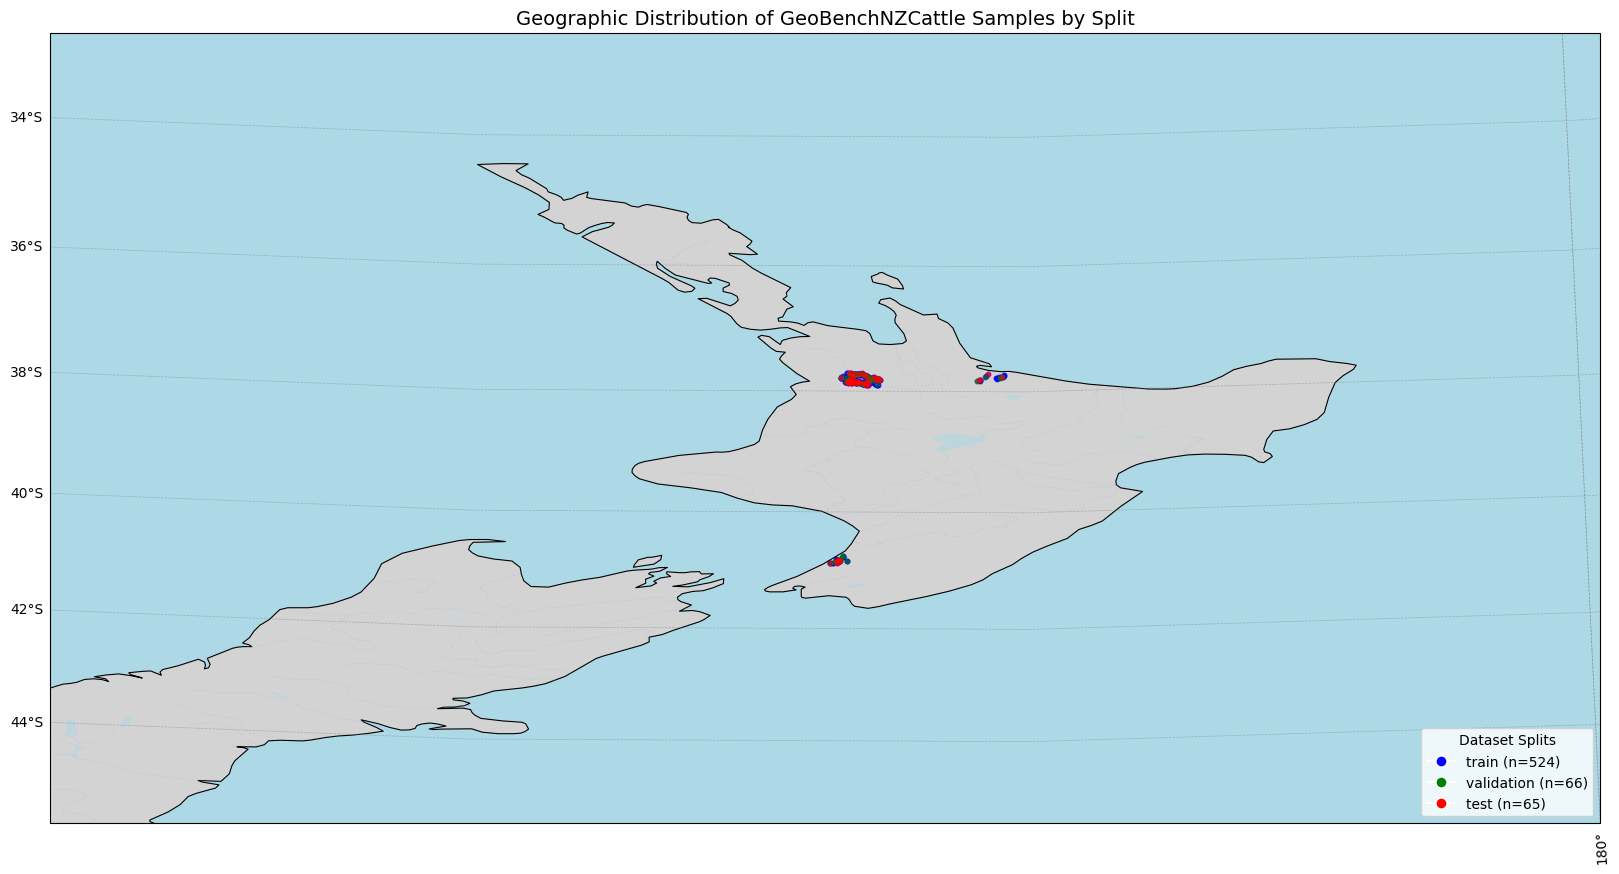

In [4]:
sample_dist_fig = datamodule.visualize_geospatial_distribution()

## Dataset Statistics

Computed over the training dataset.

### Image Statistics

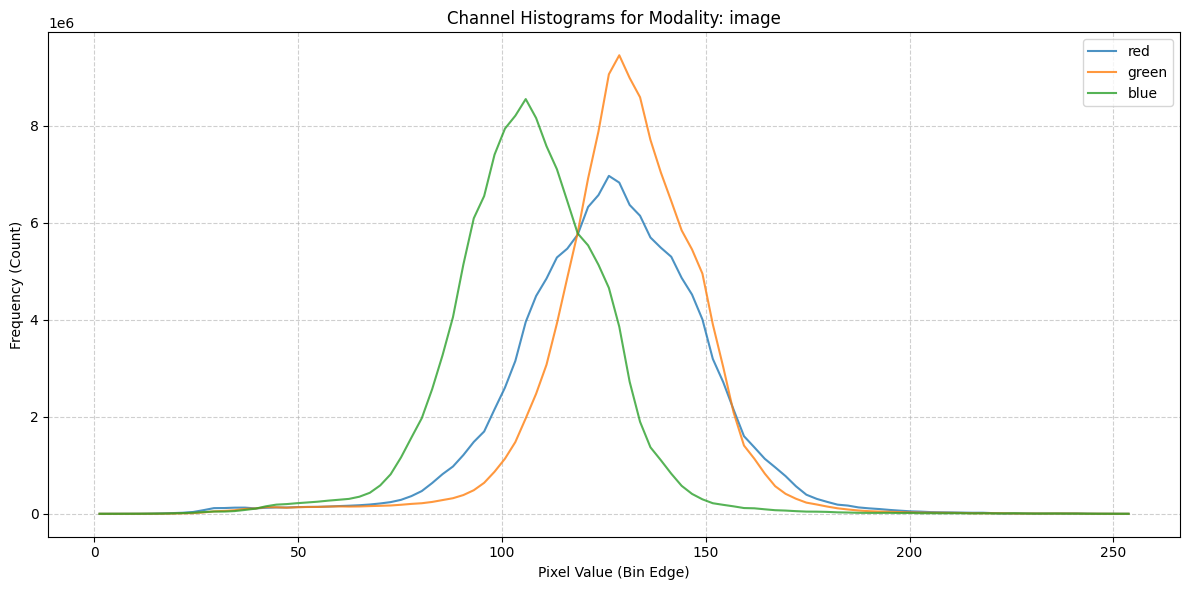

In [5]:
fig = plot_channel_histograms(STATS_SATMAE_PATH)

### Raw Batch Statistics

[<Figure size 1200x500 with 1 Axes>]

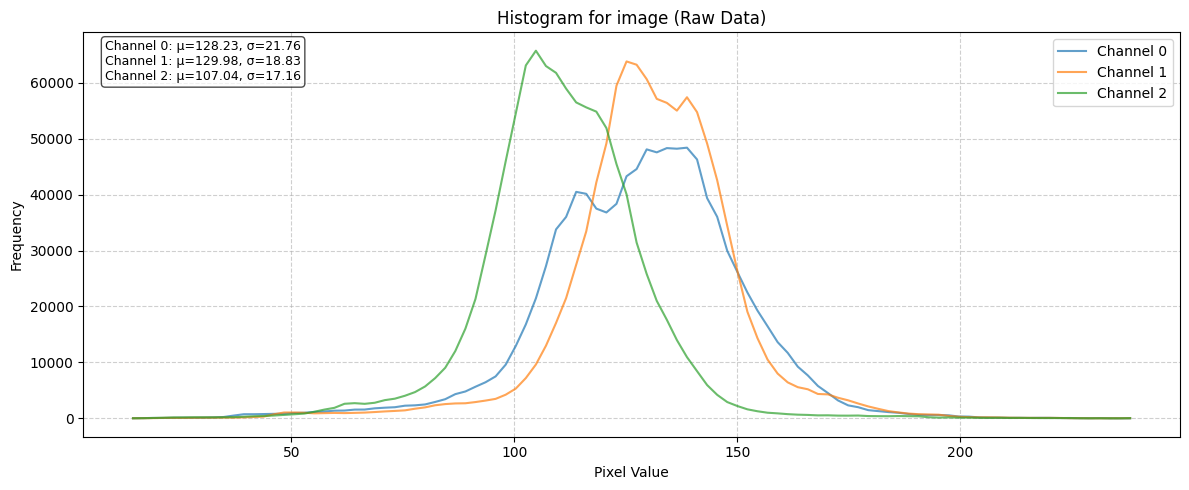

In [6]:
# Get a batch of data from the dataloader
train_dataloader = datamodule.train_dataloader()
raw_batch = next(iter(train_dataloader))

raw_batch_stats = compute_batch_histograms(raw_batch, n_bins=100)


raw_figs = plot_batch_histograms(
    raw_batch_stats, band_order, title_suffix=" (Raw Data)"
)
raw_figs

## Visualize Batch Data

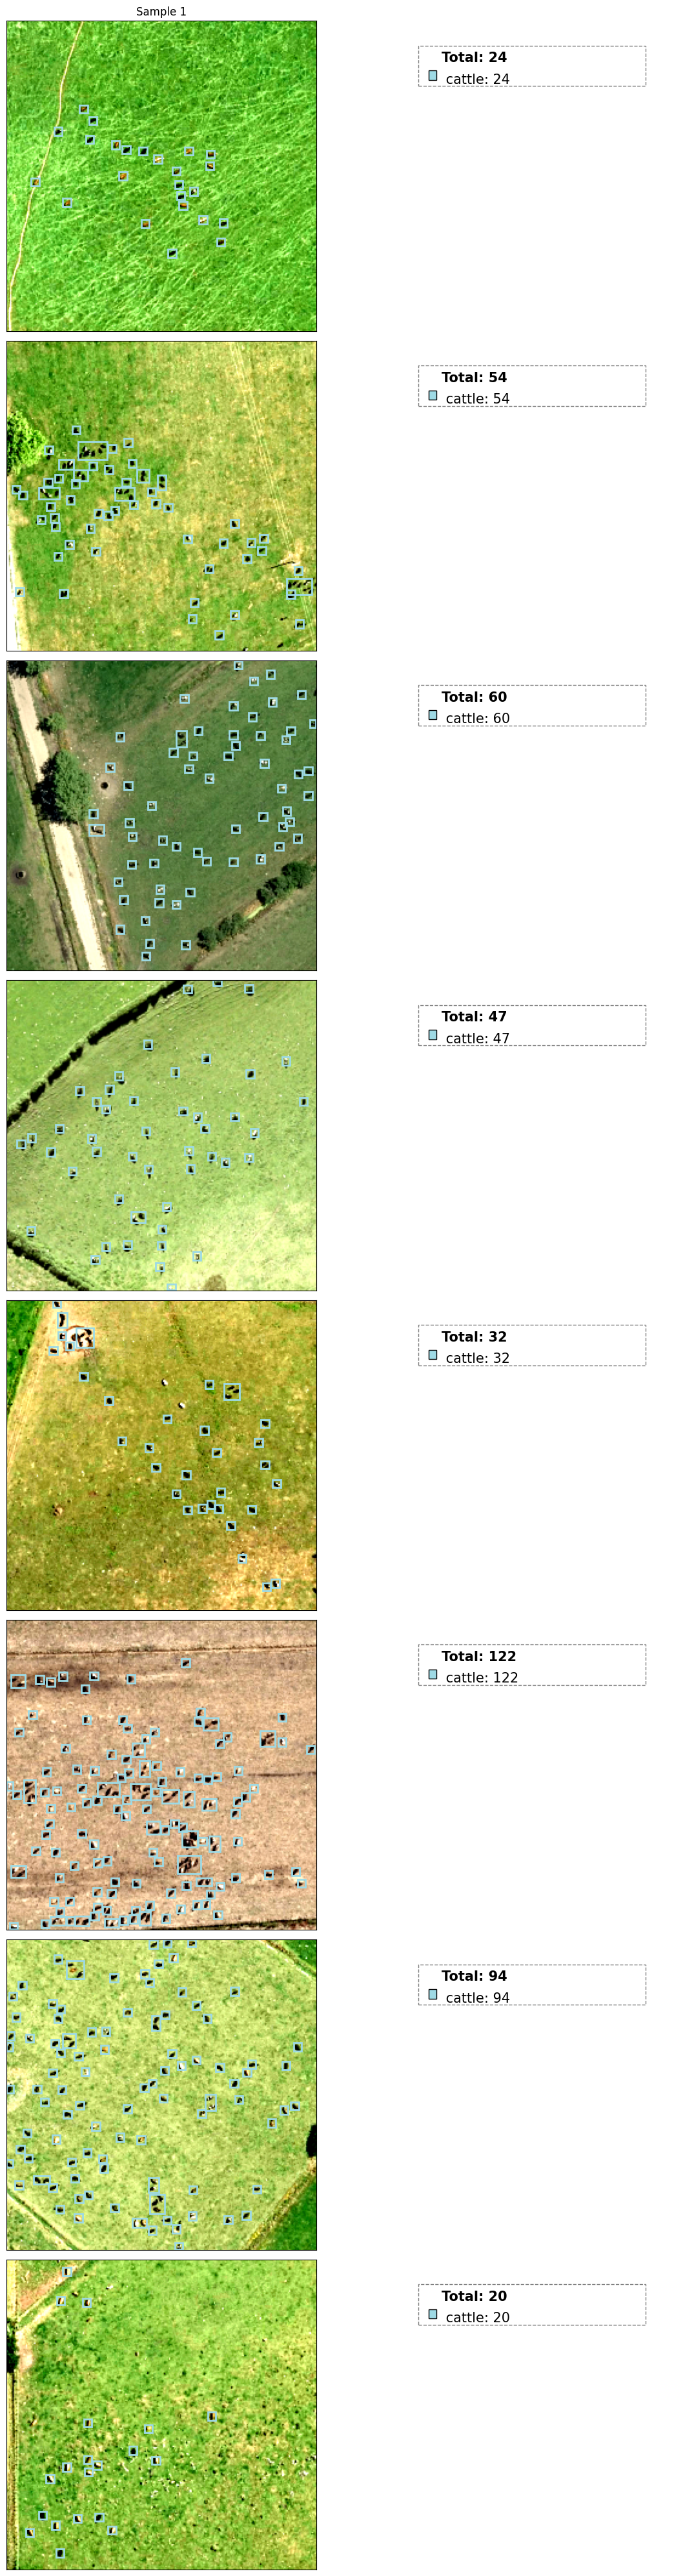

In [7]:
fig, batch = datamodule.visualize_batch()